<a href="https://colab.research.google.com/github/Jaramillo-creator/TextShield-NLP/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("spam.csv")

In [4]:
print(df.head())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
print(df.shape)

(5572, 2)


In [6]:
print(df["Category"].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


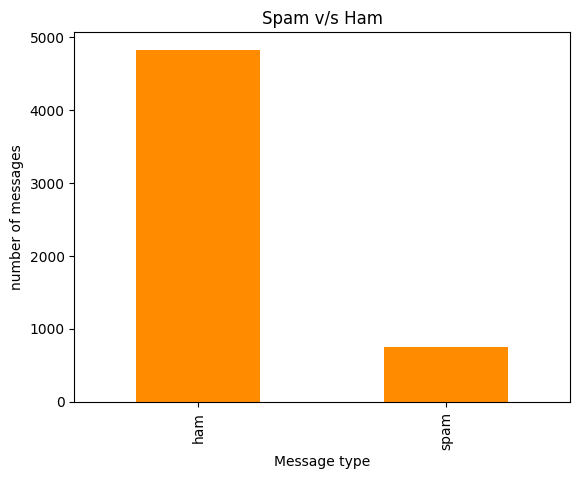

In [11]:
counts=df["Category"].value_counts()
counts.plot(kind="bar" , color="darkorange")
plt.title('Spam v/s Ham')
plt.xlabel("Message type")
plt.ylabel("number of messages")
plt.show()

In [12]:
df["Category"]=df["Category"].map({"ham":0,"spam":1})

In [13]:
x=df["Message"]
y=df["Category"]

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer(stop_words="english")
x_train_vector=vectorizer.fit_transform(x_train)
x_test_vector=vectorizer.transform(x_test)

In [16]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train_vector,y_train)

LogisticRegression(max_iter=1000)

In [17]:
predictions=model.predict(x_test_vector)

In [19]:
message=input("Enter a message: ")
message_vector=vectorizer.transform([message])
prediction=model.predict(message_vector)
if prediction[0]==1:
    print("Spam")
else:
    print("Ham")

Enter a message: Enter a message: URGENT! You have won $1000.click n ow to claim your prize! Spam
Spam


In [20]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print("Accuracy: ",accuracy)

Accuracy:  0.9838565022421525


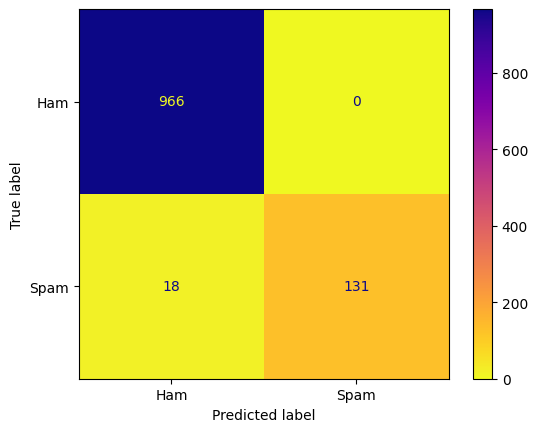

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion=confusion_matrix(y_test,predictions)
display=ConfusionMatrixDisplay(confusion_matrix=confusion,display_labels=["Ham","Spam"])
display.plot(cmap="plasma_r")
plt.show()